# Assignment M10: Neural Networks and Ensembles
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   KhramtchenkoGeorgeOPIM5604AssignmentM8.ipynb
*   KhramtchenkoGeorgeOPIM5604AssignmentM5.ipynb
*   OPIM 5604 Module 10 NN and Ensembles.ipynb
*   Google Gemini


# Environment Setup

In [2]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [3]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load the Data

**Prompt 1:** Read in the Spotify dataset and determine how many rows and columns it has.

In [20]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 10/Assignment M10/spotify-2023.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(953, 24)


**Answer:** This dataset has **953** rows and **24** columns.

Print the head elements of each column row for initial data visualization.

In [21]:
# Preview
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  ...  bpm key   mode  \
0                147  141381703               

List all columns with their corresponding data types.

In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

**Prompt 2:** The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it. Hint: if needed, drop a row of problematic data to get it to convert properly.

In [23]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

Found problematic row(s) in 'streams' column:                               track_name     artist(s)_name  artist_count  \
574  Love Grows (Where 

**Prompt 3:** Partition the data into a 60/20/20 split.

In [24]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable
target = 'streams'
features = df.drop(target, axis=1)

# Identify and drop non-numeric columns that are not suitable for direct use in a regression tree
cols_to_drop = ['track_name', 'artist(s)_name']
features = features.drop(cols_to_drop, axis=1)

# Identify columns that might contain non-numeric values that should be numeric
potential_numeric_cols = ['in_deezer_playlists', 'in_shazam_charts']

for col in potential_numeric_cols:
    # Attempt to convert to numeric, coercing errors to NaN
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Drop rows with NaN values that resulted from the coercion
features.dropna(inplace=True)
target_variable = df.loc[features.index, target] # Align target variable with cleaned features

# Identify categorical columns to encode (excluding the target variable and columns already dropped)
categorical_cols_to_encode = features.select_dtypes(include='object').columns.tolist()

# Create dummy variables for the identified categorical columns
features_encoded = pd.get_dummies(features, columns=categorical_cols_to_encode, drop_first=True)

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features_encoded, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features_encoded.head())

Training set shape: (448, 30) (448,)
Validation set shape: (150, 30) (150,)
Test set shape: (150, 30) (150,)

Encoded Features Head:
   artist_count  released_year  released_month  released_day  \
0             2           2023               7            14   
1             1           2023               3            23   
2             1           2023               6            30   
3             1           2019               8            23   
4             1           2023               5            18   

   in_spotify_playlists  in_spotify_charts  in_apple_playlists  \
0                   553                147                  43   
1                  1474                 48                  48   
2                  1397                113                  94   
3                  7858                100                 116   
4                  3133                 50                  84   

   in_apple_charts  in_deezer_playlists  in_deezer_charts  ...  key_B  key_C#  \
0   

#Neural Network

**Prompt 4:** Build a neural network to predict streams using all predictors.

*Step 1:* Standardize the predictors prior to model build.

In [25]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error # Import mean_squared_error to calculate MSE first

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Build the neural network model
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42, learning_rate_init=0.01)

# Train the model
nn_model.fit(X_train_scaled, y_train)

# Make predictions on the validation set
y_pred_val = nn_model.predict(X_val_scaled)

# Evaluate the model
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse) # Calculate RMSE
r2 = r2_score(y_val, y_pred_val)

print(f"Root Mean Squared Error on validation set: {rmse}") # Print RMSE
print(f"R-squared on validation set: {r2}")

Root Mean Squared Error on validation set: 239662484.24383676
R-squared on validation set: 0.5633938234522948


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


**Prompt 5:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on all three sets
y_pred_train = nn_model.predict(X_train_scaled)
y_pred_val = nn_model.predict(X_val_scaled)
y_pred_test = nn_model.predict(X_test_scaled)

# Evaluate performance on the training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Evaluate performance on the validation set
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

# Evaluate performance on the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Print the results
print("Neural Network Model Performance:")
print(f"  Training Set: RMSE = {rmse_train:.2f}, R-squared = {r2_train:.2f}")
print(f"  Validation Set: RMSE = {rmse_val:.2f}, R-squared = {r2_val:.2f}")
print(f"  Test Set: RMSE = {rmse_test:.2f}, R-squared = {r2_test:.2f}")

Neural Network Model Performance:
  Training Set: RMSE = 198140352.34, R-squared = 0.70
  Validation Set: RMSE = 239662484.24, R-squared = 0.56
  Test Set: RMSE = 256245562.93, R-squared = 0.50


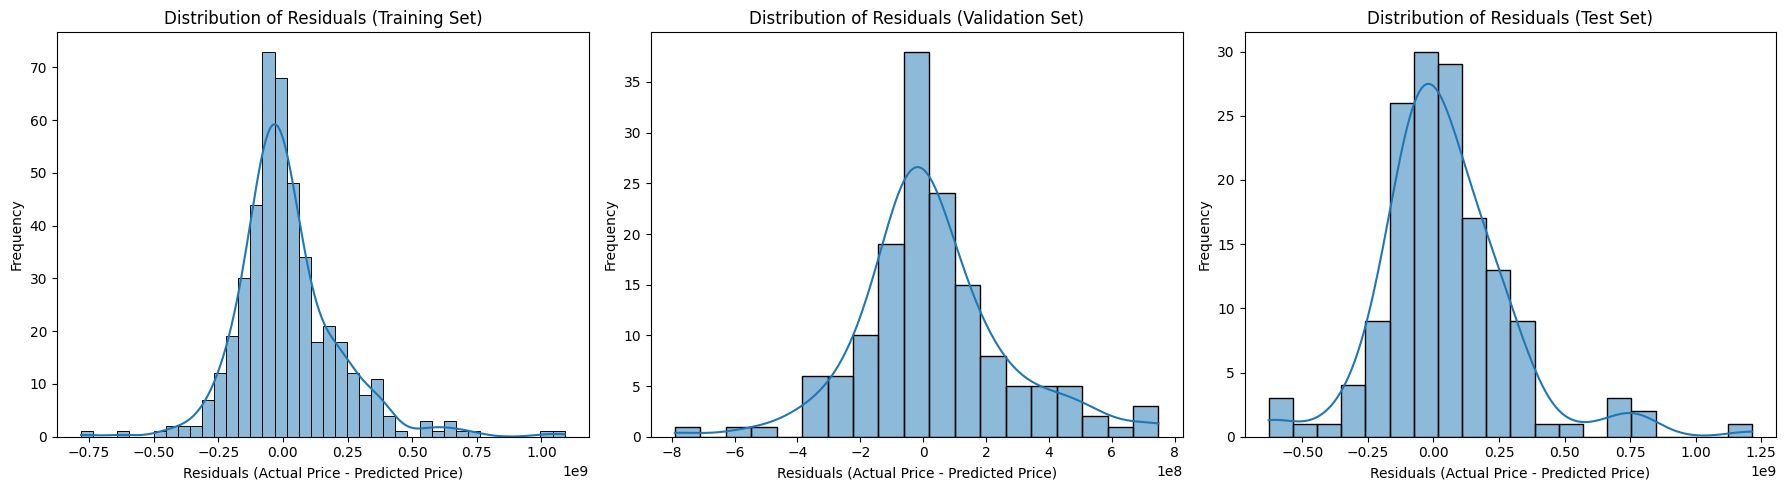


Summary Statistics of Residuals (Training Set):
count    4.480000e+02
mean     1.762661e+07
std      1.975754e+08
min     -7.808885e+08
25%     -8.790593e+07
50%     -1.118466e+07
75%      9.395402e+07
max      1.089863e+09
Name: streams, dtype: float64

Summary Statistics of Residuals (Validation Set):
count    1.500000e+02
mean     3.123664e+07
std      2.384142e+08
min     -7.896247e+08
25%     -8.551895e+07
50%      1.297729e+06
75%      1.326752e+08
max      7.480380e+08
Name: streams, dtype: float64

Summary Statistics of Residuals (Test Set):
count    1.500000e+02
mean     4.415465e+07
std      2.532583e+08
min     -6.287534e+08
25%     -9.552385e+07
50%      1.939440e+07
75%      1.623683e+08
max      1.216140e+09
Name: streams, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for all three sets
residuals_train = y_train - y_pred_train
residuals_val = y_val - y_pred_val
residuals_test = y_test - y_pred_test

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 row, 3 columns

# Plot the distribution of residuals for the training set
sns.histplot(residuals_train, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals (Training Set)')
axes[0].set_xlabel('Residuals (Actual Price - Predicted Price)')
axes[0].set_ylabel('Frequency')

# Plot the distribution of residuals for the validation set
sns.histplot(residuals_val, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals (Validation Set)')
axes[1].set_xlabel('Residuals (Actual Price - Predicted Price)')
axes[1].set_ylabel('Frequency')

# Plot the distribution of residuals for the test set
sns.histplot(residuals_test, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Residuals (Test Set)')
axes[2].set_xlabel('Residuals (Actual Price - Predicted Price)')
axes[2].set_ylabel('Frequency')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

# Also display summary statistics of residuals for all three sets
print("\nSummary Statistics of Residuals (Training Set):")
print(residuals_train.describe())

print("\nSummary Statistics of Residuals (Validation Set):")
print(residuals_val.describe())

print("\nSummary Statistics of Residuals (Test Set):")
print(residuals_test.describe())

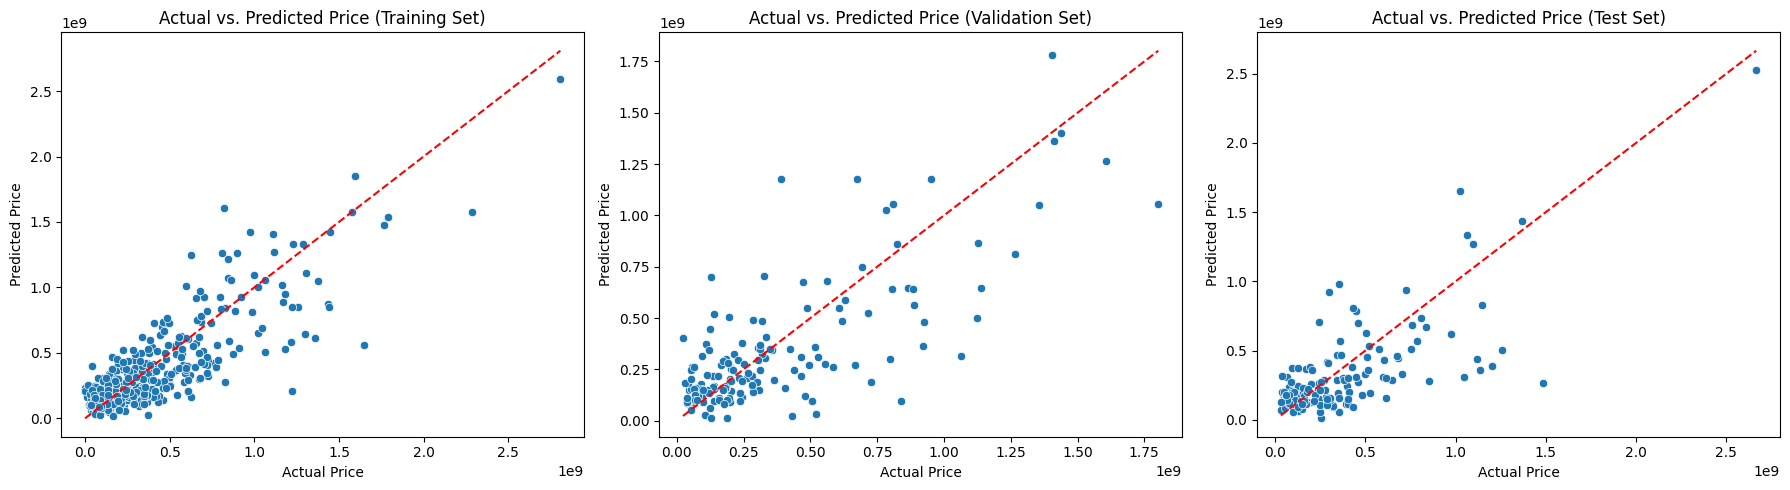

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 row, 3 columns

# Plot actual vs. predicted for the training set
sns.scatterplot(x=y_train, y=y_pred_train, ax=axes[0])
axes[0].set_title('Actual vs. Predicted Price (Training Set)')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--') # Add a diagonal line

# Plot actual vs. predicted for the validation set
sns.scatterplot(x=y_val, y=y_pred_val, ax=axes[1])
axes[1].set_title('Actual vs. Predicted Price (Validation Set)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--') # Add a diagonal line


# Plot actual vs. predicted for the test set
sns.scatterplot(x=y_test, y=y_pred_test, ax=axes[2])
axes[2].set_title('Actual vs. Predicted Price (Test Set)')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Add a diagonal line


# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

**Prompt 6:** Comment on the model performance. What did you observe in the results?

**Answer:** The model performed poorly. For R-squared, the performance fell from 0.70 for the training partition down to 0.56 and 0.50 for the validation and testing partitions, respectively.

**Prompt 7:** Build a linear regression model to predict streams.

*Step 1:* Drop the track_name, artist(s)_name, released_year, and released_month predictor columns from all the training, validation, and test partitions prior to building the linear regression model. To ensure no biased predictions are made, one-hot encode the released_month_reduced and mode columns to convert these categorical variables into a non-weighted binary format for each partition. Perform column alignment to ensure all columns retain the necessary data. Finally, set missing values present in any of the three partitions to zero and ensure the order of the columns is the same as before.

In [29]:
import pandas as pd

# Columns to drop for linear regression as per prompt
cols_to_drop_lr = ['released_year', 'released_month']

# Drop the specified columns from all partitions
# Use errors='ignore' in case a column was already dropped or doesn't exist
X_train = X_train.drop(columns=cols_to_drop_lr, errors='ignore')
X_val = X_val.drop(columns=cols_to_drop_lr, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop_lr, errors='ignore')

# One-hot encoding for 'mode' and 'key' was already performed
# in a previous step (cell HzGqGU_dctQk) when 'features_encoded' was created.
# Attempting to re-encode 'mode' (or 'key') here would result in a KeyError
# because the original 'mode' column no longer exists.
# The prompt also mentioned 'released_month_reduced', but this column does not exist,
# and the instruction was to drop 'released_month'.
# Therefore, the original pd.get_dummies calls for 'mode' and 'released_month_reduced' are removed.

# Align columns after dropping to ensure consistency across datasets.
# Collect all unique columns present across all sets.
all_columns = X_train.columns.union(X_val.columns).union(X_test.columns)

# Reindex all dataframes to include all columns, filling missing with 0.
# This also ensures consistent column order.
X_train = X_train.reindex(columns=all_columns, fill_value=0)
X_val = X_val.reindex(columns=all_columns, fill_value=0)
X_test = X_test.reindex(columns=all_columns, fill_value=0)

# The prompt also asks to set missing values present in any of the three partitions to zero.
# The reindex and fill_value=0 already handles this.

*Step 2:* Build the linear regression model.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Linear Regression with Multiple Predictors
# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the training, validation, and test sets
y_train_pred_lr = model.predict(X_train)
y_val_pred_lr = model.predict(X_val)
y_test_pred_lr = model.predict(X_test)

# Evaluate the model on the training, validation, and test sets
train_mse = mean_squared_error(y_train, y_train_pred_lr)
val_mse = mean_squared_error(y_val, y_val_pred_lr)
test_mse = mean_squared_error(y_test, y_test_pred_lr)

**Prompt 8:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

Linear Regression Model Performance:
  Training Set: RMSE = 197828466.85, R-squared = 0.71
  Validation Set: RMSE = 215902987.60, R-squared = 0.65
  Test Set: RMSE = 234498209.04, R-squared = 0.58


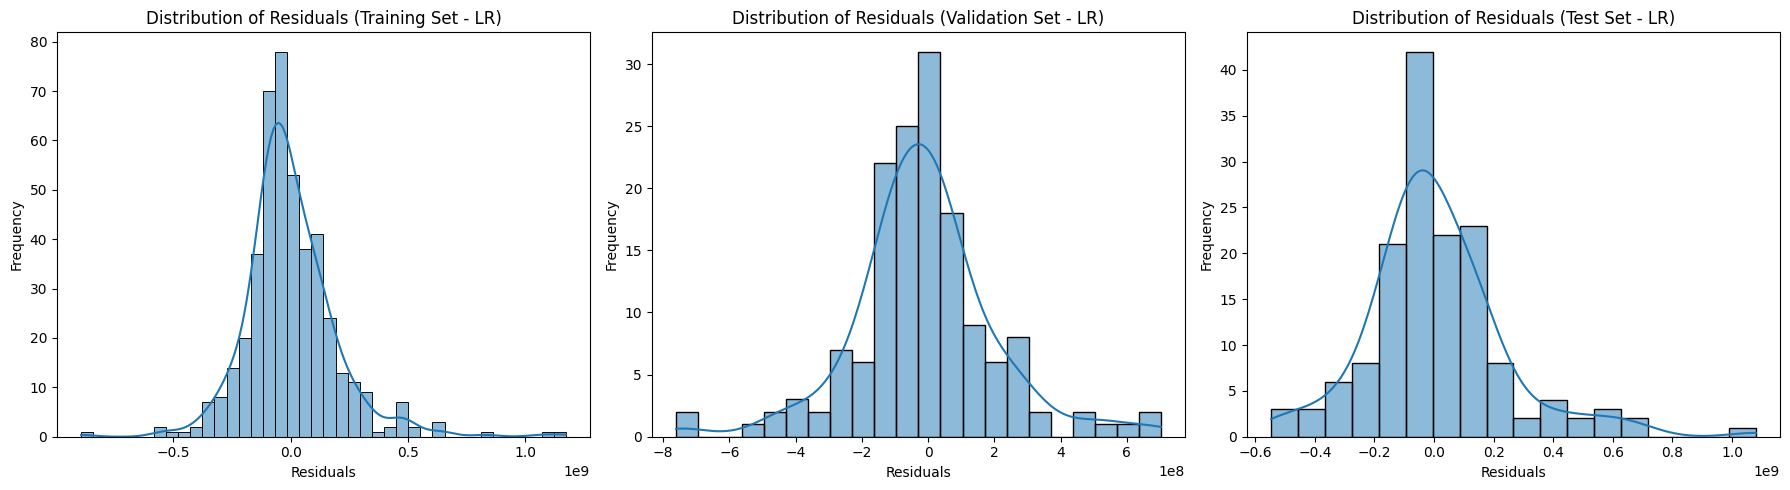

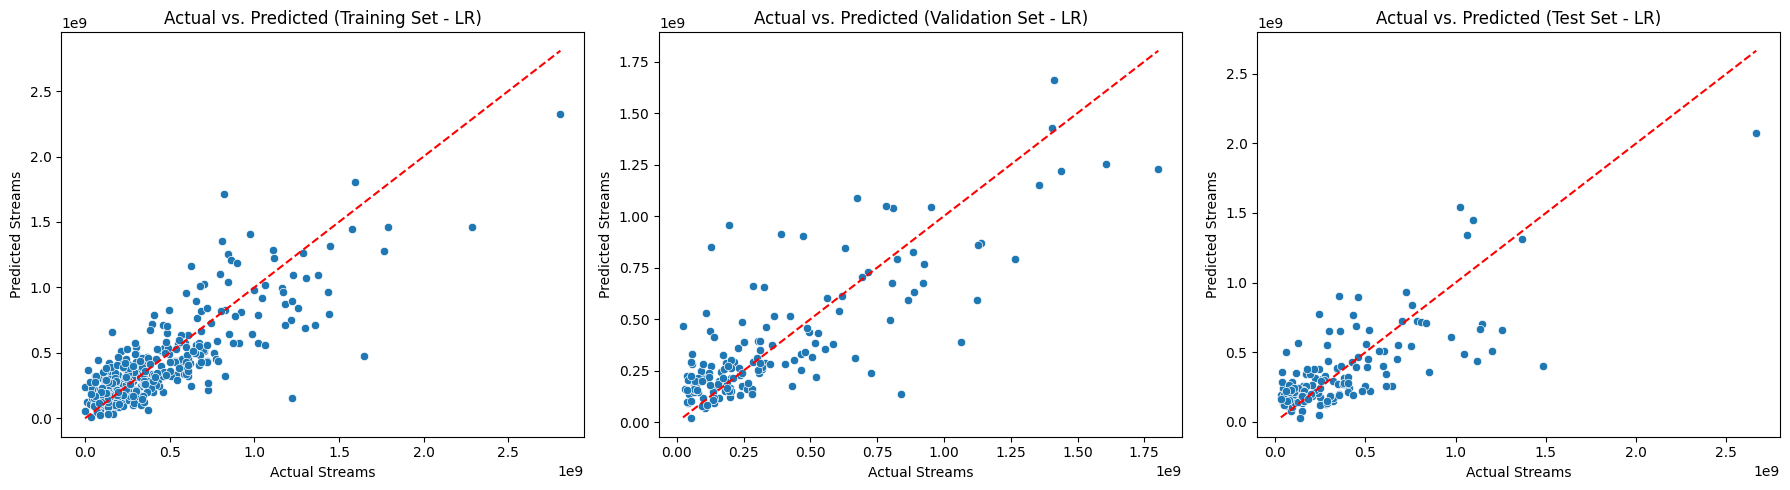

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate RMSE and R-squared for training, validation, and test sets
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_train_lr = r2_score(y_train, y_train_pred_lr)

rmse_val_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_val_lr = r2_score(y_val, y_val_pred_lr)

rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression Model Performance:")
print(f"  Training Set: RMSE = {rmse_train_lr:.2f}, R-squared = {r2_train_lr:.2f}")
print(f"  Validation Set: RMSE = {rmse_val_lr:.2f}, R-squared = {r2_val_lr:.2f}")
print(f"  Test Set: RMSE = {rmse_test_lr:.2f}, R-squared = {r2_test_lr:.2f}")

# Calculate residuals for all three sets
residuals_train_lr = y_train - y_train_pred_lr
residuals_val_lr = y_val - y_val_pred_lr
residuals_test_lr = y_test - y_test_pred_lr

# Plot the distribution of residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(residuals_train_lr, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals (Training Set - LR)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

sns.histplot(residuals_val_lr, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals (Validation Set - LR)')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

sns.histplot(residuals_test_lr, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Residuals (Test Set - LR)')
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Plot actual vs. predicted values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_train, y=y_train_pred_lr, ax=axes[0])
axes[0].set_title('Actual vs. Predicted (Training Set - LR)')
axes[0].set_xlabel('Actual Streams')
axes[0].set_ylabel('Predicted Streams')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')

sns.scatterplot(x=y_val, y=y_val_pred_lr, ax=axes[1])
axes[1].set_title('Actual vs. Predicted (Validation Set - LR)')
axes[1].set_xlabel('Actual Streams')
axes[1].set_ylabel('Predicted Streams')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')

sns.scatterplot(x=y_test, y=y_test_pred_lr, ax=axes[2])
axes[2].set_title('Actual vs. Predicted (Test Set - LR)')
axes[2].set_xlabel('Actual Streams')
axes[2].set_ylabel('Predicted Streams')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.tight_layout()
plt.show()

#Ensemble Models

**Prompt 9:** Create an ensemble model of your neural network and the linear regression.

In [32]:
# Average the predictions from the two models
y_pred_train_ensemble = (y_pred_train + y_train_pred_lr) / 2
y_pred_val_ensemble = (y_pred_val + y_val_pred_lr) / 2
y_pred_test_ensemble = (y_pred_test + y_test_pred_lr) / 2

**Prompt 10:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

Ensemble Model Performance (Averaging):
  Training Set: RMSE = 193090327.85, R-squared = 0.72
  Validation Set: RMSE = 220087912.21, R-squared = 0.63
  Test Set: RMSE = 239226277.41, R-squared = 0.56


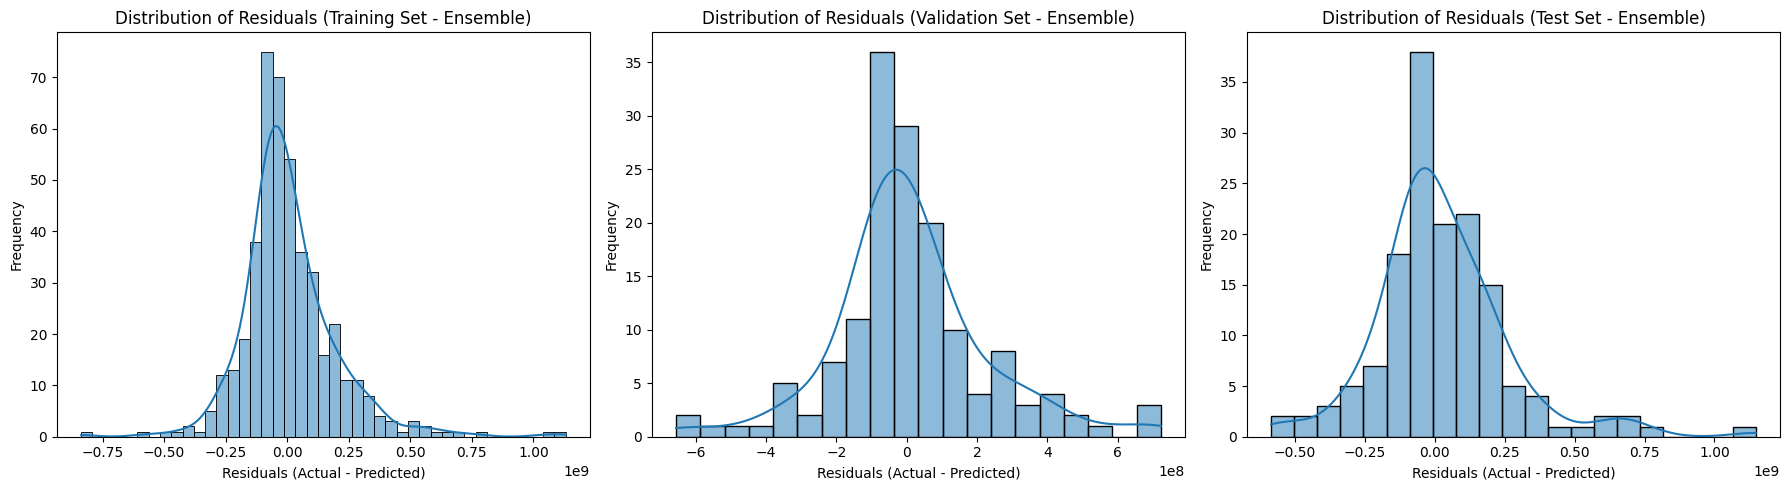

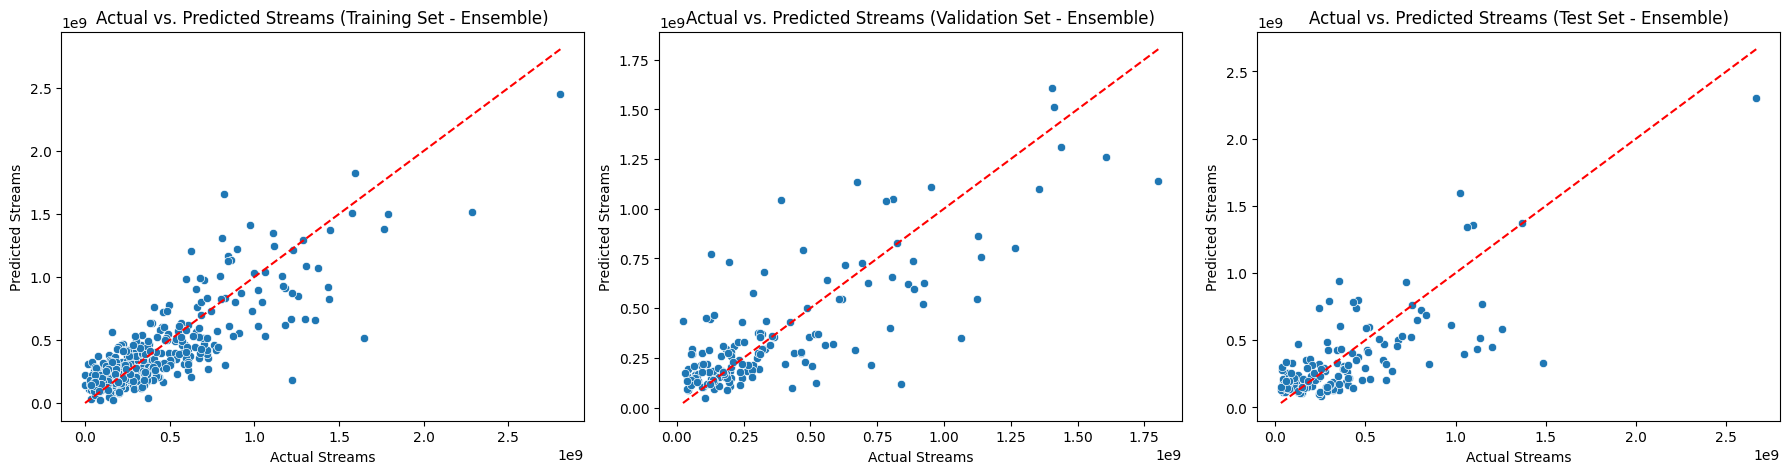

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate performance on the training set
rmse_train_ensemble = np.sqrt(mean_squared_error(y_train, y_pred_train_ensemble))
r2_train_ensemble = r2_score(y_train, y_pred_train_ensemble)

# Evaluate performance on the validation set
rmse_val_ensemble = np.sqrt(mean_squared_error(y_val, y_pred_val_ensemble))
r2_val_ensemble = r2_score(y_val, y_pred_val_ensemble)

# Evaluate performance on the test set
rmse_test_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_test_ensemble))
r2_test_ensemble = r2_score(y_test, y_pred_test_ensemble)

# Print the results
print("Ensemble Model Performance (Averaging):")
print(f"  Training Set: RMSE = {rmse_train_ensemble:.2f}, R-squared = {r2_train_ensemble:.2f}")
print(f"  Validation Set: RMSE = {rmse_val_ensemble:.2f}, R-squared = {r2_val_ensemble:.2f}")
print(f"  Test Set: RMSE = {rmse_test_ensemble:.2f}, R-squared = {r2_test_ensemble:.2f}")

# Calculate residuals for all three sets
residuals_train_ensemble = y_train - y_pred_train_ensemble
residuals_val_ensemble = y_val - y_pred_val_ensemble
residuals_test_ensemble = y_test - y_pred_test_ensemble

# Create a figure and a set of subplots for residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot the distribution of residuals for the training set
sns.histplot(residuals_train_ensemble, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals (Training Set - Ensemble)')
axes[0].set_xlabel('Residuals (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

# Plot the distribution of residuals for the validation set
sns.histplot(residuals_val_ensemble, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals (Validation Set - Ensemble)')
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

# Plot the distribution of residuals for the test set
sns.histplot(residuals_test_ensemble, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Residuals (Test Set - Ensemble)')
axes[2].set_xlabel('Residuals (Actual - Predicted)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create a figure and a set of subplots for actual vs. predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot actual vs. predicted for the training set
sns.scatterplot(x=y_train, y=y_pred_train_ensemble, ax=axes[0])
axes[0].set_title('Actual vs. Predicted Streams (Training Set - Ensemble)')
axes[0].set_xlabel('Actual Streams')
axes[0].set_ylabel('Predicted Streams')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--') # Add a diagonal line

# Plot actual vs. predicted for the validation set
sns.scatterplot(x=y_val, y=y_pred_val_ensemble, ax=axes[1])
axes[1].set_title('Actual vs. Predicted Streams (Validation Set - Ensemble)')
axes[1].set_xlabel('Actual Streams')
axes[1].set_ylabel('Predicted Streams')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--') # Add a diagonal line

# Plot actual vs. predicted for the test set
sns.scatterplot(x=y_test, y=y_pred_test_ensemble, ax=axes[2])
axes[2].set_title('Actual vs. Predicted Streams (Test Set - Ensemble)')
axes[2].set_xlabel('Actual Streams')
axes[2].set_ylabel('Predicted Streams')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Add a diagonal line

plt.tight_layout()
plt.show()

**Prompt 11:** Comment on the model performance.  What did you observe in the results?

A model comparison table is presented below to compare all three models.

In [34]:
# Create a dictionary to store the performance metrics
performance_data = {
    'Model': ['Neural Network', 'Linear Regression', 'Ensemble (Averaging)'],
    'Train RMSE': [rmse_train, rmse_train_lr, rmse_train_ensemble],
    'Train R-squared': [r2_train, r2_train_lr, r2_train_ensemble],
    'Validation RMSE': [rmse_val, rmse_val_lr, rmse_val_ensemble],
    'Validation R-squared': [r2_val, r2_val_lr, r2_val_ensemble],
    'Test RMSE': [rmse_test, rmse_test_lr, rmse_test_ensemble],
    'Test R-squared': [r2_test, r2_test_lr, r2_test_ensemble]
}

# Create a pandas DataFrame from the dictionary
performance_df = pd.DataFrame(performance_data)

# Display the DataFrame
print("Model Performance Comparison:")
display(performance_df.round(2))

Model Performance Comparison:


,Model,Train RMSE,Train R-squared,Validation RMSE,Validation R-squared,Test RMSE,Test R-squared
0,Neural Network,1.981404e+08,0.70,2.396625e+08,0.56,2.562456e+08,0.50
1,Linear Regression,1.978285e+08,0.71,2.159030e+08,0.65,2.344982e+08,0.58
2,Ensemble (Averaging),1.930903e+08,0.72,2.200879e+08,0.63,2.392263e+08,0.56


**Answer:** Through the model performance comparison seen above, the ensemble model clearly outperforms the neural network model across each partition when utilizing both the R-squared and RMSE values. In comparing the ensemble model with the linear regression model (LM), the ensemble model outperforms the test partition of the LM in the test partition with a lower RMSE and a slightly higher R-squared value. However, the validation partition of the LM observes a lower RMSE score and a higher R-squared value than the ensemble model does for validation, signifying the validation portion of the LM outperforms the ensemble model. Finally, the test portion of the LM additionally performs better than the ensemble model with a lower RMSE and a higher R-squared value.

**Prompt 12:** Compare the results of the neural network to the ensemble model.  Which one is better?  Justify your choice.

**Answer:** In conclusion, while the ensemble model outperforms the neural network confidently, it only outperforms the training partition of the LM, with validation and testing partitions showing weaker performance compared to the LM. The combination of the neural network and linear regression models in the ensemble model demonstrates superior overall performance compared to each individual model and specifically compared to the neural network model, as seen through the results and analysis presented above.